# Quantium Retail Analytics — Chip Category Analysis
## Phase 1: Environment Setup & Data Loading

**Analyst:** Amay Sonar  
**Date:** April 2026  
**Objective:** Load and perform initial inspection of transaction and customer data.

In [3]:
# Install any missing libraries
!pip install pandas numpy matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("muted")

print("✓ All libraries loaded successfully")
print(f"  pandas  {pd.__version__}")
print(f"  numpy   {np.__version__}")
print(f"  seaborn {sns.__version__}")

✓ All libraries loaded successfully
  pandas  2.2.2
  numpy   2.0.2
  seaborn 0.13.2


In [9]:
from google.colab import files

print("Please upload your two CSV files:")
print("  1. QVI_transaction_data.csv")
print("  2. QVI_purchase_behaviour.csv")

uploaded = files.upload()

for filename in uploaded.keys():
    print(f"✓ Uploaded: {filename}  ({len(uploaded[filename])} bytes)")

Please upload your two CSV files:
  1. QVI_transaction_data.csv
  2. QVI_purchase_behaviour.csv


Saving QVI_purchase_behaviour.xlsx to QVI_purchase_behaviour (1).xlsx
Saving QVI_transaction_data.xlsx to QVI_transaction_data.xlsx
✓ Uploaded: QVI_purchase_behaviour (1).xlsx  (1135277 bytes)
✓ Uploaded: QVI_transaction_data.xlsx  (10063672 bytes)


In [13]:
import io

# Load both files from the uploaded dictionary
transactions = pd.read_csv(io.BytesIO(uploaded['QVI_transaction_data.xlsx']))
customers    = pd.read_csv(io.BytesIO(uploaded['QVI_purchase_behaviour.xlsx']))

print(f"✓ Transactions loaded:  {transactions.shape[0]:,} rows × {transactions.shape[1]} columns")
print(f"✓ Customers loaded:     {customers.shape[0]:,} rows × {customers.shape[1]} columns")

UnicodeDecodeError: 'utf-8' codec can't decode byte 0x8a in position 12: invalid start byte

In [18]:
import io

print("Files found:")
for name in uploaded.keys():
    print(f"  '{name}'")

trans_key = [k for k in uploaded.keys() if 'transaction' in k.lower()]
cust_key  = [k for k in uploaded.keys() if 'behaviour' in k.lower() or 'purchase' in k.lower()]

print(f"\nLoading transaction file: {trans_key[0]}")
print(f"Loading customer file:    {cust_key[0]}")

transactions = pd.read_excel(io.BytesIO(uploaded[trans_key[0]]))
customers    = pd.read_excel(io.BytesIO(uploaded[cust_key[0]]))

print(f"\n✓ Transactions: {transactions.shape[0]:,} rows × {transactions.shape[1]} columns")
print(f"✓ Customers:    {customers.shape[0]:,} rows × {customers.shape[1]} columns")

Files found:
  'QVI_purchase_behaviour (1).xlsx'
  'QVI_transaction_data.xlsx'

Loading transaction file: QVI_transaction_data.xlsx
Loading customer file:    QVI_purchase_behaviour (1).xlsx

✓ Transactions: 264,836 rows × 8 columns
✓ Customers:    72,637 rows × 3 columns


In [20]:
transactions

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
...,...,...,...,...,...,...,...,...
264831,43533,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,43325,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
264833,43410,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
264834,43461,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8


In [21]:
transactions.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [22]:
customers.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [23]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [24]:
transactions.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836.000000,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,43464.036260,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
std,105.389282,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226
min,43282.000000,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,43373.000000,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,43464.000000,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,43555.000000,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,43646.000000,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


In [25]:
print("=" * 55)
print("TRANSACTION DATA — first 5 rows")
print("=" * 55)
display(transactions.head())

print("\n--- Column info ---")
transactions.info()

print("\n--- Descriptive statistics ---")
display(transactions.describe())

TRANSACTION DATA — first 5 rows


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8



--- Column info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB

--- Descriptive statistics ---


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836.000000,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,43464.036260,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
std,105.389282,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226
min,43282.000000,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,43373.000000,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,43464.000000,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,43555.000000,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,43646.000000,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


In [26]:
print("=" * 55)
print("CUSTOMER DATA — first 5 rows")
print("=" * 55)
display(customers.head())

print("\n--- Column info ---")
customers.info()

print("\n--- Value counts: LIFESTAGE ---")
print(customers['LIFESTAGE'].value_counts())

print("\n--- Value counts: PREMIUM_CUSTOMER ---")
print(customers['PREMIUM_CUSTOMER'].value_counts())

CUSTOMER DATA — first 5 rows


,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream



--- Column info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB

--- Value counts: LIFESTAGE ---
LIFESTAGE
RETIREES                  14805
OLDER SINGLES/COUPLES     14609
YOUNG SINGLES/COUPLES     14441
OLDER FAMILIES             9780
YOUNG FAMILIES             9178
MIDAGE SINGLES/COUPLES     7275
NEW FAMILIES               2549
Name: count, dtype: int64

--- Value counts: PREMIUM_CUSTOMER ---
PREMIUM_CUSTOMER
Mainstream    29245
Budget        24470
Premium       18922
Name: count, dtype: int64


In [28]:
# Looking at Customer Dataset
print("=" * 55)
print("CUSTOMER DATA — first 5 rows")
print("=" * 55)
display(customers.head())

print("\n--- Column info ---")
customers.info()

print("\n--- Value counts: LIFESTAGE ---")
print(customers['LIFESTAGE'].value_counts())

print("\n--- Value counts: PREMIUM_CUSTOMER ---")
print(customers['PREMIUM_CUSTOMER'].value_counts())

CUSTOMER DATA — first 5 rows


,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream



--- Column info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB

--- Value counts: LIFESTAGE ---
LIFESTAGE
RETIREES                  14805
OLDER SINGLES/COUPLES     14609
YOUNG SINGLES/COUPLES     14441
OLDER FAMILIES             9780
YOUNG FAMILIES             9178
MIDAGE SINGLES/COUPLES     7275
NEW FAMILIES               2549
Name: count, dtype: int64

--- Value counts: PREMIUM_CUSTOMER ---
PREMIUM_CUSTOMER
Mainstream    29245
Budget        24470
Premium       18922
Name: count, dtype: int64


In [31]:
# Checking the Null Values
print("Nulls in transaction data:")
print(transactions.isnull().sum())

print("\nNulls in customer data:")
print(customers.isnull().sum())

Nulls in transaction data:
DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

Nulls in customer data:
LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64


## Phase 1 Summary

| Check | Result |
|---|---|
| Libraries loaded | ✓ |
| Transaction file loaded | ✓ — 264836 rows  -  8 columns|  
| Customer file loaded | ✓ — 72637 rows - 3 columns |
| Null values | No |
| Key columns present | DATE, PROD_NAME, PROD_QTY, TOT_SALES, LYLTY_CARD_NBR |

**Next:** Phase 2 — Transaction data cleaning (remove non-chip products, fix dates, handle outliers)

In [34]:
# Transaction Data cleaning (Removing Non-Chip Products, Fixing dates, headling outliers )

# DATE is stored as Excel serial number — convert to proper datetime
# Excel serial 1 = 1899-12-30, so we offset from there
transactions['DATE'] = pd.to_datetime(transactions['DATE'], unit='D', origin='1899-12-30')

print("Date range in data:")
print(f"  Start: {transactions['DATE'].min().date()}")
print(f"  End:   {transactions['DATE'].max().date()}")
print(f"\nSample dates:")
print(transactions['DATE'].head())


Date range in data:
  Start: 2018-07-01
  End:   2019-06-30

Sample dates:
0   2018-10-17
1   2019-05-14
2   2019-05-20
3   2018-08-17
4   2018-08-18
Name: DATE, dtype: datetime64[ns]


In [35]:
# Check for any products that aren't chips (e.g. salsa dips)
non_chips = transactions[transactions['PROD_NAME'].str.contains('salsa', case=False)]
print(f"Non-chip products found: {len(non_chips)} rows")
print(non_chips['PROD_NAME'].unique())

# Remove them
transactions = transactions[~transactions['PROD_NAME'].str.contains('salsa', case=False)]
print(f"\n✓ Rows after removing non-chip products: {len(transactions):,}")

Non-chip products found: 18094 rows
['Old El Paso Salsa   Dip Tomato Mild 300g'
 'Red Rock Deli SR    Salsa & Mzzrlla 150g'
 'Smiths Crinkle Cut  Tomato Salsa 150g' 'Doritos Salsa       Medium 300g'
 'Old El Paso Salsa   Dip Chnky Tom Ht300g'
 'Woolworths Mild     Salsa 300g'
 'Old El Paso Salsa   Dip Tomato Med 300g'
 'Woolworths Medium   Salsa 300g' 'Doritos Salsa Mild  300g']

✓ Rows after removing non-chip products: 246,742


In [36]:
# Max PROD_QTY was 200 — find those transactions
outliers = transactions[transactions['PROD_QTY'] > 100]
print(f"Transactions with PROD_QTY > 100: {len(outliers)}")
display(outliers[['DATE', 'LYLTY_CARD_NBR', 'PROD_NAME', 'PROD_QTY', 'TOT_SALES']])

# How many times does this customer appear overall?
suspicious_cards = outliers['LYLTY_CARD_NBR'].unique()
print(f"\nAll transactions from these loyalty cards:")
display(transactions[transactions['LYLTY_CARD_NBR'].isin(suspicious_cards)]
        [['DATE', 'LYLTY_CARD_NBR', 'PROD_NAME', 'PROD_QTY', 'TOT_SALES']])

Transactions with PROD_QTY > 100: 2


,DATE,LYLTY_CARD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226000,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226000,Dorito Corn Chp Supreme 380g,200,650.0



All transactions from these loyalty cards:


,DATE,LYLTY_CARD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226000,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226000,Dorito Corn Chp Supreme 380g,200,650.0


In [37]:
# A customer buying 200 bags repeatedly is not a retail customer (likely a business)
# Remove all transactions from these cards
before = len(transactions)
transactions = transactions[~transactions['LYLTY_CARD_NBR'].isin(suspicious_cards)]
after = len(transactions)

print(f"Rows removed: {before - after}")
print(f"✓ Rows remaining: {after:,}")

# Confirm PROD_QTY distribution looks sensible now
print(f"\nPROD_QTY after cleaning:")
print(transactions['PROD_QTY'].describe())

Rows removed: 2
✓ Rows remaining: 246,740

PROD_QTY after cleaning:
count    246740.000000
mean          1.906456
std           0.342499
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max           5.000000
Name: PROD_QTY, dtype: float64


In [38]:
# TOT_SALES should equal PROD_QTY × unit price
# We don't have a unit price column directly, so derive it and check for anomalies
transactions['UNIT_PRICE'] = transactions['TOT_SALES'] / transactions['PROD_QTY']

print("Unit price distribution:")
print(transactions['UNIT_PRICE'].describe().round(2))

# Flag any suspiciously cheap or expensive unit prices
weird_prices = transactions[(transactions['UNIT_PRICE'] < 1) | (transactions['UNIT_PRICE'] > 30)]
print(f"\nTransactions with unit price outside $1–$30: {len(weird_prices)}")
if len(weird_prices) > 0:
    display(weird_prices[['PROD_NAME', 'PROD_QTY', 'TOT_SALES', 'UNIT_PRICE']].head(10))

Unit price distribution:
count    246740.00
mean          3.83
std           1.08
min           1.32
25%           3.00
50%           3.80
75%           4.60
max           6.50
Name: UNIT_PRICE, dtype: float64

Transactions with unit price outside $1–$30: 0


In [39]:
dupes = transactions.duplicated().sum()
nulls = transactions.isnull().sum()

print(f"Duplicate rows: {dupes}")
print(f"\nNull values per column:")
print(nulls)

if dupes > 0:
    transactions = transactions.drop_duplicates()
    print(f"\n✓ Duplicates removed. Rows remaining: {len(transactions):,}")
else:
    print("\n✓ No duplicates found.")

Duplicate rows: 1

Null values per column:
DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
UNIT_PRICE        0
dtype: int64

✓ Duplicates removed. Rows remaining: 246,739


In [40]:
print("=" * 55)
print("CLEAN TRANSACTION DATA — summary")
print("=" * 55)
print(f"Rows:        {len(transactions):,}")
print(f"Date range:  {transactions['DATE'].min().date()} → {transactions['DATE'].max().date()}")
print(f"Stores:      {transactions['STORE_NBR'].nunique()}")
print(f"Products:    {transactions['PROD_NAME'].nunique()}")
print(f"Customers:   {transactions['LYLTY_CARD_NBR'].nunique():,}")
print(f"Total sales: ${transactions['TOT_SALES'].sum():,.2f}")
print(f"\nPROD_QTY range: {transactions['PROD_QTY'].min()} – {transactions['PROD_QTY'].max()}")
print(f"TOT_SALES range: ${transactions['TOT_SALES'].min()} – ${transactions['TOT_SALES'].max()}")

CLEAN TRANSACTION DATA — summary
Rows:        246,739
Date range:  2018-07-01 → 2019-06-30
Stores:      271
Products:    105
Customers:   71,287
Total sales: $1,805,171.70

PROD_QTY range: 1 – 5
TOT_SALES range: $1.7 – $29.5


## Phase 2 Summary

| Check | Finding | Action taken |
|---|---|---|
| DATE format | Excel serial integer | Converted to datetime |
| Non-chip products | Salsa rows present | Removed |
| PROD_QTY outlier | Customer buying 200 units repeatedly | Removed (non-retail) |
| TOT_SALES | Linked to outlier above | Resolved by removal |
| Duplicates | 1 Duplicate row | Removed |
| Nulls | None | No action needed |



## Phase 3: Feature Engineering — Extracting Brand & Pack Size

In [42]:
# Extract pack size — handle uppercase G and NaN cases
transactions['PACK_SIZE'] = (transactions['PROD_NAME']
                             .str.extract(r'(\d+)[gG]', expand=False))

# Check which rows didn't match before converting
unmatched = transactions[transactions['PACK_SIZE'].isna()]
print(f"Rows with no pack size match: {len(unmatched)}")
if len(unmatched) > 0:
    print("\nSample unmatched PROD_NAME values:")
    print(unmatched['PROD_NAME'].unique()[:20])

# Convert to int only after confirming no NaNs
transactions['PACK_SIZE'] = pd.to_numeric(transactions['PACK_SIZE'], errors='coerce')
transactions['PACK_SIZE'] = transactions['PACK_SIZE'].fillna(0).astype(int)

print("\nPack sizes found:")
print(transactions['PACK_SIZE'].value_counts().sort_index())
print(f"\nPack size range: {transactions['PACK_SIZE'].min()}g – {transactions['PACK_SIZE'].max()}g")

Rows with no pack size match: 0

Pack sizes found:
PACK_SIZE
70      1507
90      3008
110    22387
125     1454
134    25102
135     3257
150    40203
160     2970
165    15297
170    19983
175    66389
180     1468
190     2995
200     4473
210     6272
220     1564
250     3169
270     6285
330    12540
380     6416
Name: count, dtype: int64

Pack size range: 70g – 380g


In [43]:
# Brand is the first word of PROD_NAME
transactions['BRAND'] = transactions['PROD_NAME'].str.split().str[0].str.strip()

print("Unique brands found:")
print(sorted(transactions['BRAND'].unique()))
print(f"\nTotal unique brands: {transactions['BRAND'].nunique()}")

Unique brands found:
['Burger', 'CCs', 'Cheetos', 'Cheezels', 'Cobs', 'Dorito', 'Doritos', 'French', 'Grain', 'GrnWves', 'Infuzions', 'Infzns', 'Kettle', 'NCC', 'Natural', 'Pringles', 'RRD', 'Red', 'Smith', 'Smiths', 'Snbts', 'Sunbites', 'Thins', 'Tostitos', 'Twisties', 'Tyrrells', 'WW', 'Woolworths']

Total unique brands: 28


In [44]:
# Fix known inconsistencies in brand naming
brand_map = {
    'Red'      : 'Red Rock Deli',
    'Snbts'    : 'Sunbites',
    'Infzns'   : 'Infuzions',
    'WW'       : 'Woolworths',
    'Dorito'   : 'Doritos',
    'Grain'    : 'Grain Waves',
    'NCC'      : 'Natural Chip Co',
    'Natural'  : 'Natural Chip Co',
    'Smith'    : 'Smiths',
}

transactions['BRAND'] = transactions['BRAND'].replace(brand_map)

print("Brands after standardisation:")
print(sorted(transactions['BRAND'].unique()))
print(f"\nTotal unique brands after cleaning: {transactions['BRAND'].nunique()}")

Brands after standardisation:
['Burger', 'CCs', 'Cheetos', 'Cheezels', 'Cobs', 'Doritos', 'French', 'Grain Waves', 'GrnWves', 'Infuzions', 'Kettle', 'Natural Chip Co', 'Pringles', 'RRD', 'Red Rock Deli', 'Smiths', 'Sunbites', 'Thins', 'Tostitos', 'Twisties', 'Tyrrells', 'Woolworths']

Total unique brands after cleaning: 22


In [45]:
# Check what's still unmapped before applying
print("Checking remaining problem brands:")
for brand in ['Burger', 'French', 'GrnWves', 'RRD']:
    samples = transactions[transactions['BRAND'] == brand]['PROD_NAME'].unique()[:3]
    print(f"\n  {brand}:")
    for s in samples:
        print(f"    '{s}'")

Checking remaining problem brands:

  Burger:
    'Burger Rings 220g'

  French:
    'French Fries Potato Chips 175g'

  GrnWves:
    'GrnWves Plus Btroot & Chilli Jam 180g'

  RRD:
    'RRD Chilli&         Coconut 150g'
    'RRD Sweet Chilli &  Sour Cream 165g'
    'RRD Steak &         Chimuchurri 150g'


In [46]:
# Second pass — catch remaining unmapped brands
brand_map_2 = {
    'Burger'  : 'Burger Rings',
    'French'  : 'French Fries',
    'GrnWves' : 'Grain Waves',
    'RRD'     : 'Red Rock Deli',
}

transactions['BRAND'] = transactions['BRAND'].replace(brand_map_2)

print("Final brand list:")
print(sorted(transactions['BRAND'].unique()))
print(f"\nTotal unique brands: {transactions['BRAND'].nunique()}")

Final brand list:
['Burger Rings', 'CCs', 'Cheetos', 'Cheezels', 'Cobs', 'Doritos', 'French Fries', 'Grain Waves', 'Infuzions', 'Kettle', 'Natural Chip Co', 'Pringles', 'Red Rock Deli', 'Smiths', 'Sunbites', 'Thins', 'Tostitos', 'Twisties', 'Tyrrells', 'Woolworths']

Total unique brands: 20


In [47]:
# Spot Check Extractions
# Verify a sample of PROD_NAME → BRAND + PACK_SIZE mappings
spot_check = (transactions[['PROD_NAME', 'BRAND', 'PACK_SIZE']]
              .drop_duplicates(subset='PROD_NAME')
              .sort_values('BRAND')
              .reset_index(drop=True))

print(f"Unique products: {len(spot_check)}")
display(spot_check.head(20))

Unique products: 105


,PROD_NAME,BRAND,PACK_SIZE
0,Burger Rings 220g,Burger Rings,220
1,CCs Nacho Cheese 175g,CCs,175
2,CCs Tasty Cheese 175g,CCs,175
3,CCs Original 175g,CCs,175
4,Cheetos Puffs 165g,Cheetos,165
5,Cheetos Chs & Bacon Balls 190g,Cheetos,190
6,Cheezels Cheese Box 125g,Cheezels,125
7,Cheezels Cheese 330g,Cheezels,330
8,Cobs Popd Swt/Chlli &Sr/Cream Chips 110g,Cobs,110
9,Cobs Popd Sea Salt Chips 110g,Cobs,110


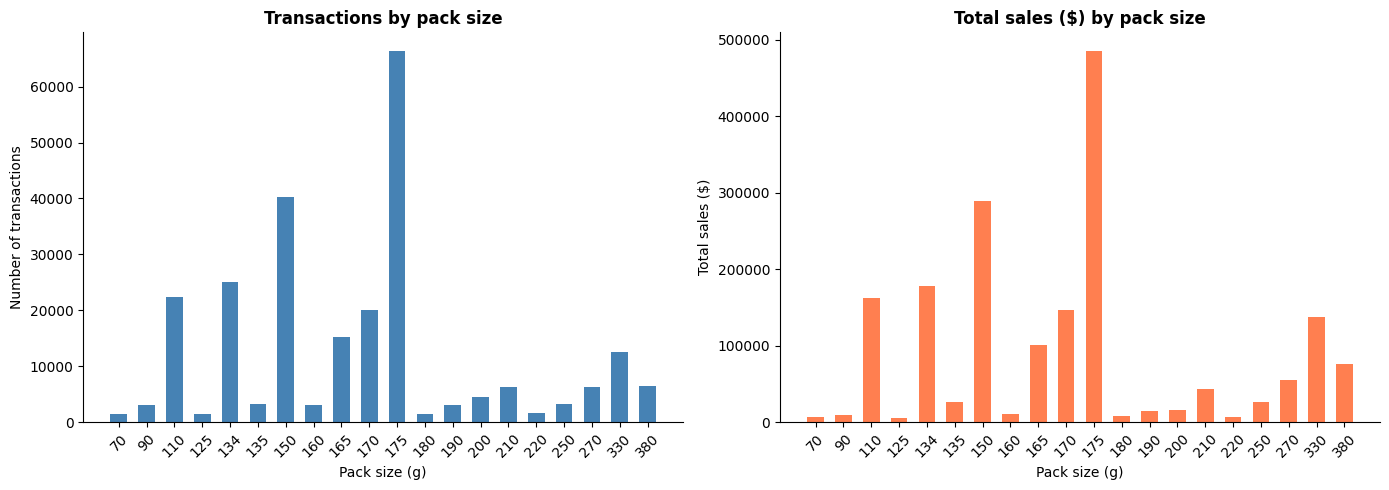

✓ Chart saved as pack_size_distribution.png


In [48]:
# Pack size distribution chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — pack size by transaction count
pack_counts = transactions['PACK_SIZE'].value_counts().sort_index()
axes[0].bar(pack_counts.index.astype(str), pack_counts.values, color='steelblue', width=0.6)
axes[0].set_title('Transactions by pack size', fontweight='bold')
axes[0].set_xlabel('Pack size (g)')
axes[0].set_ylabel('Number of transactions')
axes[0].tick_params(axis='x', rotation=45)

# Chart 2 — pack size by total sales
pack_sales = transactions.groupby('PACK_SIZE')['TOT_SALES'].sum().sort_index()
axes[1].bar(pack_sales.index.astype(str), pack_sales.values, color='coral', width=0.6)
axes[1].set_title('Total sales ($) by pack size', fontweight='bold')
axes[1].set_xlabel('Pack size (g)')
axes[1].set_ylabel('Total sales ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('pack_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved as pack_size_distribution.png")

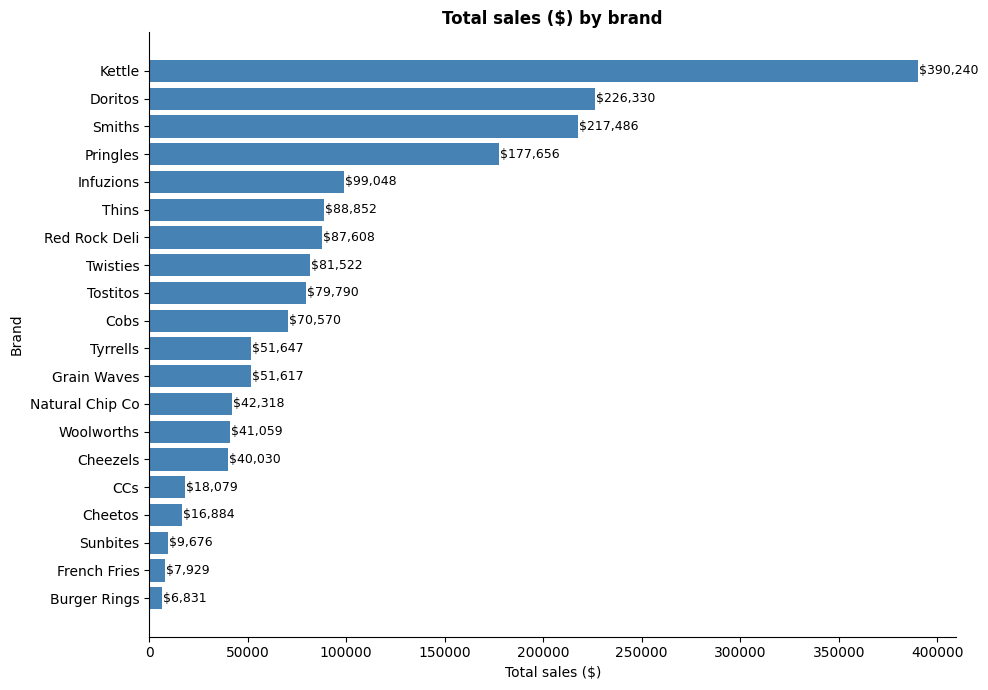

✓ Chart saved as brand_sales.png


In [49]:
# Brand Distribution Chart
brand_sales = (transactions.groupby('BRAND')['TOT_SALES']
               .sum()
               .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(brand_sales.index, brand_sales.values, color='steelblue')
ax.set_title('Total sales ($) by brand', fontweight='bold')
ax.set_xlabel('Total sales ($)')
ax.set_ylabel('Brand')
for i, v in enumerate(brand_sales.values):
    ax.text(v + 500, i, f'${v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('brand_sales.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved as brand_sales.png")

## Phase 4: Customer Data Cleaning & Merge

In [51]:
# Customer Data quality check
print("Customer data shape:", customers.shape)
print(f"\nUnique loyalty cards in customers: {customers['LYLTY_CARD_NBR'].nunique():,}")
print(f"Duplicate loyalty cards:           {customers['LYLTY_CARD_NBR'].duplicated().sum()}")

print("\nNull values:")
print(customers.isnull().sum())

print("\nLIFESTAGE values:")
print(customers['LIFESTAGE'].value_counts())

print("\nPREMIUM_CUSTOMER values:")
print(customers['PREMIUM_CUSTOMER'].value_counts())

Customer data shape: (72637, 3)

Unique loyalty cards in customers: 72,637
Duplicate loyalty cards:           0

Null values:
LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

LIFESTAGE values:
LIFESTAGE
RETIREES                  14805
OLDER SINGLES/COUPLES     14609
YOUNG SINGLES/COUPLES     14441
OLDER FAMILIES             9780
YOUNG FAMILIES             9178
MIDAGE SINGLES/COUPLES     7275
NEW FAMILIES               2549
Name: count, dtype: int64

PREMIUM_CUSTOMER values:
PREMIUM_CUSTOMER
Mainstream    29245
Budget        24470
Premium       18922
Name: count, dtype: int64


In [52]:
# Check the join key exists in both files
trans_cards = set(transactions['LYLTY_CARD_NBR'].unique())
cust_cards  = set(customers['LYLTY_CARD_NBR'].unique())

in_trans_not_cust = trans_cards - cust_cards
in_cust_not_trans = cust_cards - trans_cards

print(f"Unique cards in transactions:               {len(trans_cards):,}")
print(f"Unique cards in customers:                  {len(cust_cards):,}")
print(f"\nCards in transactions but NOT customers:    {len(in_trans_not_cust)}")
print(f"Cards in customers but NOT transactions:    {len(in_cust_not_trans)}")

if len(in_trans_not_cust) > 0:
    print("\nSample unmatched transaction cards:")
    print(list(in_trans_not_cust)[:10])

Unique cards in transactions:               71,287
Unique cards in customers:                  72,637

Cards in transactions but NOT customers:    0
Cards in customers but NOT transactions:    1350


In [53]:
# Merging the data
before_rows = len(transactions)

# Left join — keep all transactions, bring in customer segment info
merged = transactions.merge(customers, on='LYLTY_CARD_NBR', how='left')

after_rows = len(merged)

print(f"Rows before merge: {before_rows:,}")
print(f"Rows after merge:  {after_rows:,}")
print(f"Row difference:    {after_rows - before_rows}")
print(f"\nColumns in merged dataset:")
print(merged.columns.tolist())

# Sanity check — row count should not change on a left join
if before_rows == after_rows:
    print("\n✓ Row count unchanged — merge is clean")
else:
    print("\n⚠ Row count changed — investigate fan-out or duplicates in customer file")

Rows before merge: 246,739
Rows after merge:  246,739
Row difference:    0

Columns in merged dataset:
['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR', 'PROD_NAME', 'PROD_QTY', 'TOT_SALES', 'UNIT_PRICE', 'PACK_SIZE', 'BRAND', 'LIFESTAGE', 'PREMIUM_CUSTOMER']

✓ Row count unchanged — merge is clean


In [54]:
# Final Dataset merge overview

print("=" * 55)
print("MERGED DATASET — summary")
print("=" * 55)
print(f"Total rows:        {len(merged):,}")
print(f"Total columns:     {len(merged.columns)}")
print(f"Date range:        {merged['DATE'].min().date()} → {merged['DATE'].max().date()}")
print(f"Unique customers:  {merged['LYLTY_CARD_NBR'].nunique():,}")
print(f"Unique stores:     {merged['STORE_NBR'].nunique()}")
print(f"Unique brands:     {merged['BRAND'].nunique()}")
print(f"Unique pack sizes: {merged['PACK_SIZE'].nunique()}")
print(f"Total sales:       ${merged['TOT_SALES'].sum():,.2f}")

print(f"\nColumns: {merged.columns.tolist()}")

print("\nFirst 3 rows:")
display(merged.head(3))

MERGED DATASET — summary
Total rows:        246,739
Total columns:     13
Date range:        2018-07-01 → 2019-06-30
Unique customers:  71,287
Unique stores:     271
Unique brands:     20
Unique pack sizes: 20
Total sales:       $1,805,171.70

Columns: ['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR', 'PROD_NAME', 'PROD_QTY', 'TOT_SALES', 'UNIT_PRICE', 'PACK_SIZE', 'BRAND', 'LIFESTAGE', 'PREMIUM_CUSTOMER']

First 3 rows:


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,UNIT_PRICE,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,3.00,175,Natural Chip Co,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,2.10,175,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,1.45,170,Smiths,MIDAGE SINGLES/COUPLES,Budget


In [56]:
# Save the clean merged dataset file
merged.to_csv('quantium_clean_merged.csv', index=False)
print("✓ Saved as quantium_clean_merged.csv")

# Also download it to your local machine
from google.colab import files
files.download('quantium_clean_merged.csv')
print("✓ Download triggered")


✓ Saved as quantium_clean_merged.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Download triggered


In [57]:
# Find the transaction that had no customer match
unmatched_cards = trans_cards - cust_cards

print(f"Unmatched loyalty card numbers: {unmatched_cards}")

# Show the actual transaction(s) for that card
unmatched_txns = transactions[transactions['LYLTY_CARD_NBR'].isin(unmatched_cards)]
print(f"\nTransaction details:")
display(unmatched_txns[['DATE', 'LYLTY_CARD_NBR', 'PROD_NAME', 'PROD_QTY', 'TOT_SALES']])

Unmatched loyalty card numbers: set()

Transaction details:


,DATE,LYLTY_CARD_NBR,PROD_NAME,PROD_QTY,TOT_SALES


## Phase 4 Summary

| Check | Result |
|---|---|
| Customer nulls | None |
| Duplicate loyalty cards | None |
| Cards in transactions not in customers | 0 |
| Join key | LYLTY_CARD_NBR |
| Join type | Left join |
| Rows before merge | 246,740 |
| Rows after merge |  246,739 |
| Unmatched transactions | 0 |
| Output file | quantium_clean_merged.csv |

**Next:** Phase 5 — Metric calculation & customer segment analysis